# Workflow graph analysis — single profile JSON

Adapts section 5 of `gemini_rag_run_analysis.ipynb` to the current schema (`metadata` block + `nodes_source`, `nodes_process`, `nodes_sink`). Point `JSON_PATH` at any profile written by the current `gemini_rag.py` and re-run.

Graph layers:
- **source** — from `nodes_source[*].node_id` (`src_*`)
- **process** — from `nodes_process[*].node_id` (`meth_<NN>`); each process node carries a `process_type` of `method` or `experiment`
- **sink** — from `nodes_sink[*].node_id` (`sink_fig*` / `sink_tab*`); the `type` field discriminates figure vs table

Edges are materialised from each process step's `input_ids` / `outcomes`: every `src_*` label connects its source node to this step, every intermediate label matches an earlier step's outcome, every `sink_*` label connects this step to its sink.

In [1]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

## 1. Load profile

In [2]:
# --- change this path to analyse any profile on disk ---------------------
JSON_PATH = Path("data/specific_cases/simple_paper_exe5.profile.json")
# -------------------------------------------------------------------------

assert JSON_PATH.exists(), f"missing: {JSON_PATH}"
profile = json.loads(JSON_PATH.read_text())

meta = profile.get("metadata", {})
src_nodes = profile.get("nodes_source", [])
proc_nodes = profile.get("nodes_process", [])
sink_items = profile.get("nodes_sink", [])
fig_nodes = [s for s in sink_items if s.get("type") == "figure"]
tab_nodes = [s for s in sink_items if s.get("type") == "table"]

n_method_steps = sum(1 for p in proc_nodes if p.get("process_type") == "method")
n_exp_steps = sum(1 for p in proc_nodes if p.get("process_type") == "experiment")

print(f"File:        {JSON_PATH.name}")
print(f"Title:       {meta.get('title', '')[:100]}")
print(f"Model:       {meta.get('extraction_model', '')}")
print(f"Sources:     {len(src_nodes)}")
print(f"Processes:   {len(proc_nodes)}  (methods={n_method_steps}, experiments={n_exp_steps})")
print(f"Figures:     {len(fig_nodes)}")
print(f"Tables:      {len(tab_nodes)}")

File:        simple_paper_exe5.profile.json
Title:       A Deep Reinforcement Learning Approach for Ramp Metering Based on Traffic Video Data
Model:       gemini-3-flash-preview
Sources:     1
Processes:   4  (methods=3, experiments=1)
Figures:     8
Tables:      1


## 2. Build the 4-layer graph

In [3]:
def _norm(s: str) -> str:
    return " ".join(s.lower().split())


def _process_id(s: dict, fallback_index: int) -> str:
    """Return the step's node_id, synthesising one from 'order' (legacy schema) if needed."""
    nid = s.get("node_id")
    if isinstance(nid, str) and nid:
        return nid
    order = s.get("order", fallback_index + 1)
    try:
        return f"meth_{int(order):02d}"
    except (TypeError, ValueError):
        return f"meth_{fallback_index + 1:02d}"


def _process_inputs(s: dict) -> list[str]:
    return list(s.get("input_ids") or s.get("data_inputs") or [])


def _process_outcomes(s: dict) -> list[str]:
    return list(s.get("outcomes") or s.get("expected_outputs") or [])


def _process_label(s: dict, mid: str) -> str:
    name = s.get("node_name") or s.get("description", "")[:60]
    return f"{mid} {name}".strip()


def _source_label(s: dict, sid: str) -> str:
    """Prefer node_name (current schema), fall back to legacy 'name'."""
    return s.get("node_name") or s.get("name") or sid


def build_workflow_graph(profile: dict) -> nx.DiGraph:
    """Directed graph over source / process / sink nodes with explicit IDs.

    Process IDs come from nodes_process[*].node_id ('meth_<NN>') under the
    current schema, or are synthesised from 'order' for legacy profiles.
    Edges come from string-match between a step's input_ids/outcomes and
    either a src_/sink_ id or an earlier step's outcome label.
    """
    g = nx.DiGraph()

    src_ids = set()
    for s in profile.get("nodes_source", []):
        sid = s["node_id"]
        src_ids.add(sid)
        g.add_node(sid, layer="source", label=_source_label(s, sid))

    sink_ids = set()
    for item in profile.get("nodes_sink", []):
        sid = item["node_id"]
        sink_ids.add(sid)
        kind = item.get("type") or ("figure" if sid.startswith("sink_fig") else "table")
        label = item.get("node_name") or sid
        g.add_node(sid, layer="sink", kind=kind, label=label)

    raw_steps = list(profile.get("nodes_process", []))
    steps = sorted(
        enumerate(raw_steps),
        key=lambda iv: _process_id(iv[1], iv[0]),
    )
    procs = []
    for idx, s in steps:
        mid = _process_id(s, idx)
        ins = [_norm(x) for x in _process_inputs(s)]
        outs = [_norm(x) for x in _process_outcomes(s)]
        g.add_node(
            mid,
            layer="process",
            process_type=s.get("process_type", "method"),
            label=_process_label(s, mid),
            input_ids=ins,
            outcomes=outs,
        )
        procs.append((mid, ins, outs))

    for mid, ins, outs in procs:
        for lbl in ins:
            if lbl in src_ids:
                g.add_edge(lbl, mid, kind="source_input")
        for lbl in outs:
            if lbl in sink_ids:
                g.add_edge(mid, lbl, kind="sink_output")

    for i, (mi, _, outs_i) in enumerate(procs):
        outs_set = set(outs_i) - src_ids - sink_ids
        if not outs_set:
            continue
        for j, (mj, ins_j, _) in enumerate(procs):
            if i == j:
                continue
            shared = outs_set & set(ins_j)
            if shared:
                g.add_edge(mi, mj, kind="intermediate", labels=sorted(shared))

    return g


g = build_workflow_graph(profile)
print(f"Nodes: {g.number_of_nodes()}  (sources={sum(1 for _,d in g.nodes(data=True) if d['layer']=='source')}, "
      f"processes={sum(1 for _,d in g.nodes(data=True) if d['layer']=='process')}, "
      f"sinks={sum(1 for _,d in g.nodes(data=True) if d['layer']=='sink')})")
print(f"Edges: {g.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(g)}")

Nodes: 14  (sources=1, processes=4, sinks=9)
Edges: 14
Is DAG: True


## 3. Wiring quality — how well is the graph connected across layers?

These metrics answer: does every declared source feed a method? does every method produce (directly or transitively) a sink? are any `input_ids` labels unresolved (neither a source id nor an upstream method's outcome)?

In [4]:
def wiring_metrics(g: nx.DiGraph) -> dict:
    by_layer = {l: [v for v, d in g.nodes(data=True) if d["layer"] == l]
                for l in ("source", "process", "sink")}
    src = by_layer["source"]
    proc = by_layer["process"]
    snk = by_layer["sink"]

    # Sources consumed = those with at least one outgoing edge.
    src_used = [v for v in src if g.out_degree(v) > 0]
    # Sinks produced = those with at least one incoming edge.
    snk_made = [v for v in snk if g.in_degree(v) > 0]

    # Resolved inputs / produced outcomes across nodes_process.
    all_outs = set()
    for _, d in g.nodes(data=True):
        if d["layer"] == "process":
            all_outs.update(d["outcomes"])
    src_ids = set(src)
    sink_ids = set(snk)
    known = src_ids | sink_ids | all_outs

    tot_in = tot_out = dangling_in = deadend_out = 0
    for _, d in g.nodes(data=True):
        if d["layer"] != "process":
            continue
        for lbl in d["input_ids"]:
            tot_in += 1
            if lbl not in known:
                dangling_in += 1
        for lbl in d["outcomes"]:
            tot_out += 1
            # Consumed = appears as some process's input, or IS a sink id.
            consumed = lbl in sink_ids or any(
                lbl in g.nodes[m]["input_ids"] for m in proc
            )
            if not consumed:
                deadend_out += 1

    # Reachability source→sink: fraction of (src, sink) pairs with a directed path.
    if src and snk:
        reach = sum(nx.has_path(g, s, t) for s in src for t in snk) / (len(src) * len(snk))
    else:
        reach = 0.0

    return {
        "n_sources": len(src),
        "n_sources_consumed": len(src_used),
        "sources_consumed_ratio": round(len(src_used) / len(src), 3) if src else 0.0,
        "n_sinks": len(snk),
        "n_sinks_produced": len(snk_made),
        "sinks_produced_ratio": round(len(snk_made) / len(snk), 3) if snk else 0.0,
        "n_process_inputs": tot_in,
        "n_dangling_inputs": dangling_in,
        "resolved_input_ratio": round(1.0 - dangling_in / tot_in, 3) if tot_in else 0.0,
        "n_process_outputs": tot_out,
        "n_deadend_outputs": deadend_out,
        "consumed_output_ratio": round(1.0 - deadend_out / tot_out, 3) if tot_out else 0.0,
        "source_to_sink_reachability": round(reach, 3),
    }


wm = wiring_metrics(g)
pd.Series(wm, name="value").to_frame()

,value
n_sources,1.0
n_sources_consumed,1.0
sources_consumed_ratio,1.0
n_sinks,9.0
n_sinks_produced,9.0
sinks_produced_ratio,1.0
n_process_inputs,5.0
n_dangling_inputs,0.0
resolved_input_ratio,1.0
n_process_outputs,12.0


## 4. Flow metrics — efficiency and connectivity

Subset of the Section 3 (old notebook) family, applied to the 4-layer graph.

In [ ]:
def flow_metrics(g: nx.DiGraph) -> dict:
    n = g.number_of_nodes()
    if n == 0:
        return {"lwcc_fraction": 0.0, "global_efficiency_undirected": 0.0,
                "reachability_ratio": 0.0, "density": 0.0, "longest_path_len": 0}

    u = g.to_undirected()
    wccs = list(nx.weakly_connected_components(g))
    lwcc = max((len(c) for c in wccs), default=0)

    try:
        eff_u = nx.global_efficiency(u)
    except Exception:
        eff_u = 0.0

    if n >= 2:
        reachable = sum(len(nx.descendants(g, v)) for v in g.nodes)
        reach = 
        / (n * (n - 1))
    else:
        reach = 0.0

    longest = nx.dag_longest_path_length(g) if nx.is_directed_acyclic_graph(g) else None

    return {
        "lwcc_fraction": round(lwcc / n, 3),
        "global_efficiency_undirected": round(eff_u, 3),
        "reachability_ratio": round(reach, 3),
        "density": round(nx.density(g), 3),
        "longest_path_len": longest,
    }


fm = flow_metrics(g)
pd.Series(fm, name="value").to_frame()

,value
lwcc_fraction,1.000
global_efficiency_undirected,0.544
reachability_ratio,0.302
density,0.077
longest_path_len,5.000


## 5. Composite reproducibility index

Combines two complementary signals into a single index in `[0, 1]`:

1. **Structural quality (wiring)** — does the graph hold together? Same five-component weighted sum as before; each component targets a graph-shape failure mode.
2. **Content quality (per-node reproducibility)** — weighted mean of the `reproducibility_score` values the analyst assigns to every source, method, and sink. Per-layer weights `0.30 / 0.40 / 0.30` (sources / methods / sinks); methods carry the most weight because they encode the implementation contract.

The full **reproducibility index** is the geometric mean of the two:

`reproducibility_index = sqrt(structural × content)`

Geometric form ensures both must be non-zero. A paper with perfect wiring but unspecified parameters scores low; so does a paper with fully stated parameters but a broken graph.

| weight | structural component | failure it penalises |
|---|---|---|
| 0.25 | `sources_consumed_ratio` | declared dataset never used |
| 0.25 | `sinks_produced_ratio` | claimed figure/table with no producing step |
| 0.20 | `resolved_input_ratio` | method consumes a label nothing produced |
| 0.15 | `source_to_sink_reachability` | chain broken between inputs and outputs |
| 0.15 | `lwcc_fraction` | graph fragmented into disconnected pieces |

In [6]:
import math

# 1. STRUCTURAL quality -- weighted graph-shape components, in [0, 1].
structural = (
    0.25 * wm["sources_consumed_ratio"]
    + 0.25 * wm["sinks_produced_ratio"]
    + 0.20 * wm["resolved_input_ratio"]
    + 0.15 * wm["source_to_sink_reachability"]
    + 0.15 * fm["lwcc_fraction"]
)

# 2. CONTENT quality -- per-layer mean of the analyst's reproducibility_score
#    (0..100), normalised to [0, 1]. Returns None for empty layers so weights
#    can be re-normalised over the layers that actually exist.
def _layer_repro_mean(items: list) -> float | None:
    if not items:
        return None
    scores = [int(it.get("reproducibility_score", 0)) for it in items]
    return (sum(scores) / len(scores)) / 100.0


layer_repro = {
    "source":  _layer_repro_mean(profile.get("nodes_source", [])),
    "process": _layer_repro_mean(profile.get("nodes_process", [])),
    "sink":    _layer_repro_mean(profile.get("nodes_sink", [])),
}
LAYER_W = {"source": 0.30, "process": 0.40, "sink": 0.30}
present = {k: r for k, r in layer_repro.items() if r is not None}
if present:
    total_w = sum(LAYER_W[k] for k in present)
    content = sum(LAYER_W[k] * r / total_w for k, r in present.items())
else:
    content = 0.0

# 3. FULL reproducibility index = geometric mean of structural and content.
score = math.sqrt(max(0.0, structural) * max(0.0, content))

print(f"File:    {JSON_PATH.name}")
print(f"Nodes:   {g.number_of_nodes()}  Edges: {g.number_of_edges()}")
print()
print(f"{'REPRODUCIBILITY INDEX':<34} {score:>7.3f}   (range 0–1, geometric)")
print("=" * 50)
print(f"{'STRUCTURAL (wiring)':<34} {structural:>7.3f}")
print("-" * 50)
print(f"  sources_consumed_ratio     (w=0.25)  {wm['sources_consumed_ratio']:>7.3f}")
print(f"  sinks_produced_ratio       (w=0.25)  {wm['sinks_produced_ratio']:>7.3f}")
print(f"  resolved_input_ratio       (w=0.20)  {wm['resolved_input_ratio']:>7.3f}")
print(f"  source_to_sink_reachability(w=0.15)  {wm['source_to_sink_reachability']:>7.3f}")
print(f"  lwcc_fraction              (w=0.15)  {fm['lwcc_fraction']:>7.3f}")
print()
print(f"{'CONTENT (per-node mean)':<34} {content:>7.3f}")
print("-" * 50)
for k in ("source", "process", "sink"):
    r = layer_repro[k]
    label = f"  {k}s mean reproducibility   (w={LAYER_W[k]:.2f})"
    print(f"{label:<38}{r if r is not None else float('nan'):>7.3f}"
          if r is not None else f"{label:<38}     n/a")

File:    simple_paper_exe5.profile.json
Nodes:   14  Edges: 14

REPRODUCIBILITY INDEX                0.827   (range 0–1, geometric)
STRUCTURAL (wiring)                  1.000
--------------------------------------------------
  sources_consumed_ratio     (w=0.25)    1.000
  sinks_produced_ratio       (w=0.25)    1.000
  resolved_input_ratio       (w=0.20)    1.000
  source_to_sink_reachability(w=0.15)    1.000
  lwcc_fraction              (w=0.15)    1.000

CONTENT (per-node mean)              0.683
--------------------------------------------------
  sources mean reproducibility   (w=0.30)  0.500
  processs mean reproducibility   (w=0.40)  0.850
  sinks mean reproducibility   (w=0.30)  0.644


## 6. Visualisation — layered layout

Sources on top (green), process steps in the middle (grey for `method`, orange-ish for `experiment`), sinks at the bottom (red for figure, blue for table).

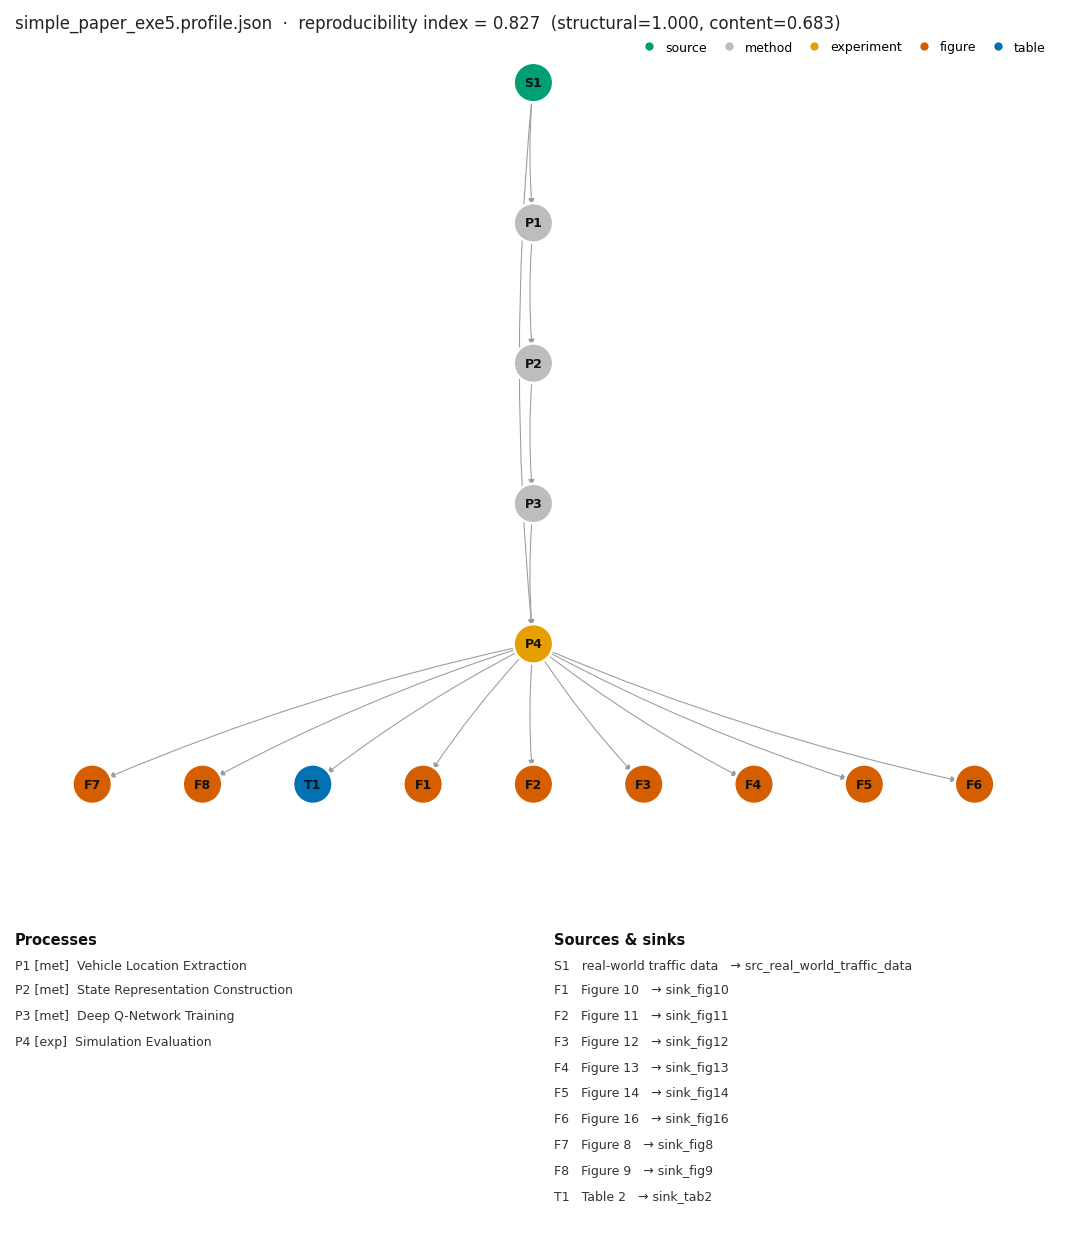

In [7]:
import matplotlib as mpl
import textwrap

NATURE_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 8,
    "legend.fontsize": 6,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

LAYER_COLOR = {
    "source":     "#009E73",
    "method":     "#BDBDBD",
    "experiment": "#E69F00",
    "figure":     "#D55E00",
    "table":      "#0072B2",
}

LAYER_Y_GAP = 1.6  # vertical spacing between layers (data coords)


def node_color(d: dict) -> str:
    if d["layer"] == "source":
        return LAYER_COLOR["source"]
    if d["layer"] == "process":
        return LAYER_COLOR.get(d.get("process_type", "method"), LAYER_COLOR["method"])
    return LAYER_COLOR["figure"] if d.get("kind") == "figure" else LAYER_COLOR["table"]


def tree_pos(g: nx.DiGraph) -> dict:
    """Top-down Sugiyama layout. Sinks forced to the deepest row."""
    if g.number_of_nodes() == 0:
        return {}
    depth = {v: 0 for v in g.nodes if g.in_degree(v) == 0}
    for v in nx.topological_sort(g):
        for w in g.successors(v):
            depth[w] = max(depth.get(w, 0), depth.get(v, 0) + 1)
    sinks = [v for v, d in g.nodes(data=True) if d.get("layer") == "sink"]
    if sinks:
        max_other = max((depth[v] for v in g.nodes if v not in sinks), default=0)
        for v in sinks:
            depth[v] = max(depth[v], max_other + 1)
    max_d = max(depth.values(), default=0)

    by_layer: dict[int, list] = {}
    for v, d in depth.items():
        by_layer.setdefault(d, []).append(v)

    pos, prev_x = {}, {}
    for d in range(max_d + 1):
        nodes = by_layer.get(d, [])
        if d == 0:
            nodes.sort()
        else:
            def _bary(v: str) -> float:
                ps = [prev_x[p] for p in g.predecessors(v) if p in prev_x]
                return sum(ps) / len(ps) if ps else 0.5
            nodes.sort(key=_bary)
        n = len(nodes)
        for i, v in enumerate(nodes):
            x = (i + 1) / (n + 1)
            pos[v] = (x, -d * LAYER_Y_GAP)
            prev_x[v] = x
    return pos


def _code_map(g: nx.DiGraph) -> dict[str, str]:
    """Assign compact 2-3 char codes per layer: S1..Sn, P1..Pn, F1..Fn, T1..Tn."""
    code: dict[str, str] = {}
    for prefix, layer, kind in [("S", "source", None), ("P", "process", None),
                                ("F", "sink", "figure"), ("T", "sink", "table")]:
        members = sorted(
            v for v, d in g.nodes(data=True)
            if d["layer"] == layer and (kind is None or d.get("kind") == kind)
        )
        for i, v in enumerate(members, start=1):
            code[v] = f"{prefix}{i}"
    return code


def _wrap(text: str, width: int) -> str:
    return "\n".join(textwrap.wrap(text or "", width=width)) or "—"


with mpl.rc_context(NATURE_RC):
    pos = tree_pos(g)
    code = _code_map(g)

    sources = sorted((v for v, d in g.nodes(data=True) if d["layer"] == "source"), key=lambda v: code[v])
    processes = sorted((v for v, d in g.nodes(data=True) if d["layer"] == "process"), key=lambda v: code[v])
    sinks = sorted((v for v, d in g.nodes(data=True) if d["layer"] == "sink"), key=lambda v: code[v])

    # figure sizing: width driven by widest layer, height by depth + legend rows
    widest = max((sum(1 for v in g.nodes if pos[v][1] == y)
                  for y in {p[1] for p in pos.values()}), default=1) if pos else 1
    n_depths = len({p[1] for p in pos.values()}) if pos else 1
    leg_rows = max(len(processes), len(sources) + len(sinks))
    fig_w = max(6.5, min(7.2, 0.75 * widest + 3.0))
    fig_h = 0.75 + 0.95 * n_depths + 0.22 * leg_rows
    fig_h = min(fig_h, 10.0)

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(
        2, 1, height_ratios=[0.95 * n_depths + 0.5, 0.22 * leg_rows + 0.2], hspace=0.18
    )
    ax = fig.add_subplot(gs[0])
    ax_leg = fig.add_subplot(gs[1])
    ax_leg.axis("off")

    if g.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "empty graph", ha="center", va="center", fontsize=8)
        ax.axis("off")
    else:
        nx.draw_networkx_edges(
            g, pos, ax=ax, arrows=True, arrowsize=6, arrowstyle="-|>",
            edge_color="#9a9a9a", width=0.5,
            connectionstyle="arc3,rad=0.05",
            min_source_margin=7, min_target_margin=7,
        )
        colors = [node_color(d) for _, d in g.nodes(data=True)]
        nx.draw_networkx_nodes(
            g, pos, ax=ax, node_color=colors, node_size=360,
            edgecolors="white", linewidths=1.2,
        )
        nx.draw_networkx_labels(
            g, pos, labels=code, ax=ax,
            font_size=6, font_color="#111", font_weight="bold",
        )

        xs = [x for x, _ in pos.values()]
        ys = [y for _, y in pos.values()]
        ax.set_xlim(min(xs) - 0.07, max(xs) + 0.07)
        ax.set_ylim(min(ys) - 0.55, max(ys) + 0.55)
        ax.axis("off")
        ax.set_title(
            f"{JSON_PATH.name}  ·  reproducibility index = {score:.3f}  "
            f"(structural={structural:.3f}, content={content:.3f})",
            fontsize=8, loc="left", pad=3, color="#222",
        )

        handles = [
            plt.Line2D([0], [0], marker="o", linestyle="", markersize=5,
                       markerfacecolor=LAYER_COLOR[k], markeredgecolor="white", label=lbl)
            for k, lbl in [("source", "source"), ("method", "method"),
                           ("experiment", "experiment"),
                           ("figure", "figure"), ("table", "table")]
        ]
        ax.legend(
            handles=handles, loc="upper right", frameon=False, ncol=5,
            handletextpad=0.3, columnspacing=0.7, borderaxespad=0.1,
        )

        # legend panel: two columns (processes | sources+sinks) with headers
        x_left, x_right = 0.0, 0.52
        n_rows_total = max(len(processes) + 1, len(sources) + len(sinks) + 1)
        row_h = 1.0 / (n_rows_total + 1)

        ax_leg.text(x_left, 1.0, "Processes", fontsize=7, fontweight="bold",
                    transform=ax_leg.transAxes, va="top", color="#111")
        for i, v in enumerate(processes):
            desc = g.nodes[v].get("label", "") or v
            # strip the leading node_id prefix (e.g. 'meth_01 ') from the stored label
            if desc.startswith(v + " "):
                desc = desc[len(v) + 1:]
            ptype = g.nodes[v].get("process_type", "method")
            ax_leg.text(
                x_left, 1.0 - (i + 1) * row_h,
                f"{code[v]} [{ptype[:3]}]  {_wrap(desc, 65).splitlines()[0][:65]}",
                fontsize=6, transform=ax_leg.transAxes, va="top", color="#333",
                family="sans-serif",
            )

        ax_leg.text(x_right, 1.0, "Sources & sinks", fontsize=7, fontweight="bold",
                    transform=ax_leg.transAxes, va="top", color="#111")
        row = 0
        for v in sources:
            name = g.nodes[v].get("label", v)
            ax_leg.text(
                x_right, 1.0 - (row + 1) * row_h,
                f"{code[v]}   {name[:55]}   → {v}",
                fontsize=6, transform=ax_leg.transAxes, va="top", color="#333",
            )
            row += 1
        for v in sinks:
            name = g.nodes[v].get("label", v)
            ax_leg.text(
                x_right, 1.0 - (row + 1) * row_h,
                f"{code[v]}   {name[:55]}   → {v}",
                fontsize=6, transform=ax_leg.transAxes, va="top", color="#333",
            )
            row += 1

    plt.subplots_adjust(left=0.02, right=0.98, top=0.96, bottom=0.03)
    plt.show()


## 7. Orphan / dangling report

Lists concrete IDs that break the wiring — these are the ones to diff between extraction runs to see whether prompt changes help.

In [8]:
src_ids = {v for v, d in g.nodes(data=True) if d["layer"] == "source"}
sink_ids = {v for v, d in g.nodes(data=True) if d["layer"] == "sink"}
process_ids = [v for v, d in g.nodes(data=True) if d["layer"] == "process"]
all_outs = set()
for v in process_ids:
    all_outs.update(g.nodes[v]["outcomes"])

orphan_sources = sorted(v for v in src_ids if g.out_degree(v) == 0)
unproduced_sinks = sorted(v for v in sink_ids if g.in_degree(v) == 0)

unresolved = []  # (process_id, label)
deadend = []     # (process_id, label)
invented_src_like = []
invented_sink_like = []
for v in process_ids:
    ins = g.nodes[v]["input_ids"]
    outs = g.nodes[v]["outcomes"]
    for lbl in ins:
        if lbl in src_ids or lbl in all_outs or lbl in sink_ids:
            continue
        unresolved.append((v, lbl))
        if lbl.startswith("src_"):
            invented_src_like.append((v, lbl))
    for lbl in outs:
        consumed = lbl in sink_ids or any(
            lbl in g.nodes[m]["input_ids"] for m in process_ids
        )
        if not consumed:
            deadend.append((v, lbl))
        if lbl.startswith("sink_") and lbl not in sink_ids:
            invented_sink_like.append((v, lbl))

print(f"Orphan sources (declared but never consumed): {len(orphan_sources)}")
for v in orphan_sources:
    print(f"  - {v}")
print(f"\nUnproduced sinks (claimed but never produced): {len(unproduced_sinks)}")
for v in unproduced_sinks:
    print(f"  - {v}")
print(f"\nUnresolved process inputs (no matching source/outcome/sink): {len(unresolved)}")
for m, lbl in unresolved:
    print(f"  - {m} ← {lbl!r}")
print(f"\nDead-end process outcomes (never consumed, not a sink): {len(deadend)}")
for m, lbl in deadend:
    print(f"  - {m} → {lbl!r}")
print(f"\nInvented src_* ids (looks like a source but not declared): {len(invented_src_like)}")
for m, lbl in invented_src_like:
    print(f"  - {m} ← {lbl!r}")
print(f"\nInvented sink_* ids (looks like a sink but not declared): {len(invented_sink_like)}")
for m, lbl in invented_sink_like:
    print(f"  - {m} → {lbl!r}")

Orphan sources (declared but never consumed): 0

Unproduced sinks (claimed but never produced): 0

Unresolved process inputs (no matching source/outcome/sink): 0

Dead-end process outcomes (never consumed, not a sink): 0

Invented src_* ids (looks like a source but not declared): 0

Invented sink_* ids (looks like a sink but not declared): 0


## 8. Process clarity report

Per-step view of the `nodes_process` fields that aren't visible in the graph itself:

- `process_type` — `method` vs `experiment` classification.
- `algorithm_clarity` — ordinal reconstructability score r(.) on a 4-level scale: `1` missing, `2` partial, `3` mostly specified, `4` sufficient for independent reconstruction.
- `tools_required` vs `tools_mentioned` — gap between generic techniques needed and concrete libraries named in the paper.
- `parameters_required` vs `parameters_mentioned` — which parameter names the technique needs vs which values the paper actually states.

Steps where `tools_required` is non-empty but `tools_mentioned` is empty, or where `parameters_required` outnumbers `parameters_mentioned`, mark reproducibility gaps even when the graph wiring is intact.

In [9]:
def _clarity_int(c) -> int:
    """Coerce algorithm_clarity to the 4-level ordinal int. Missing -> 1."""
    if isinstance(c, bool):  # bool is a subclass of int
        return 1
    if isinstance(c, int):
        return c
    try:
        return int(c)
    except (TypeError, ValueError):
        return 1


rows = []
for idx, s in enumerate(proc_nodes):
    mid = _process_id(s, idx)
    tools_req = s.get("tools_required") or []
    tools_men = s.get("tools_mentioned") or []
    pars_req = s.get("parameters_required") or []
    pars_men = s.get("parameters_mentioned") or []
    rows.append({
        "node_id": mid,
        "process_type": s.get("process_type", "method"),
        "node_name": (s.get("node_name") or s.get("description", ""))[:40],
        "clarity": _clarity_int(s.get("algorithm_clarity", 1)),
        "n_tools_req": len(tools_req),
        "n_tools_men": len(tools_men),
        "tool_gap": max(0, len(tools_req) - len(tools_men)),
        "n_pars_req": len(pars_req),
        "n_pars_men": len(pars_men),
        "param_gap": max(0, len(pars_req) - len(pars_men)),
    })

df_clarity = pd.DataFrame(rows).sort_values("node_id").set_index("node_id")
print("Per-step process clarity")
print("-" * 60)
print(df_clarity.to_string())

n_steps = max(1, len(df_clarity))
mean_recon = df_clarity["clarity"].mean()
# Normalise the 1..4 ordinal to [0, 1] via (r - 1) / 3.
clarity_score = (mean_recon - 1) / 3
tool_gap_ratio = df_clarity["tool_gap"].sum() / max(1, df_clarity["n_tools_req"].sum())
param_gap_ratio = df_clarity["param_gap"].sum() / max(1, df_clarity["n_pars_req"].sum())

print()
print(f"mean reconstructability r(.)       {mean_recon:.3f}   (1=missing, 4=sufficient)")
print(f"normalised clarity score           {clarity_score:.3f}   (0=all missing, 1=all sufficient)")
print(f"tool-naming gap     (0=all named)  {tool_gap_ratio:.3f}")
print(f"parameter-value gap (0=all stated) {param_gap_ratio:.3f}")

Per-step process clarity
------------------------------------------------------------
        process_type                          node_name  clarity  n_tools_req  n_tools_men  tool_gap  n_pars_req  n_pars_men  param_gap
node_id                                                                                                                                
meth_01       method        Vehicle Location Extraction        3            1            0         1           1           1          0
meth_02       method  State Representation Construction        4            1            0         1           1           1          0
meth_03       method            Deep Q-Network Training        4            4            2         2           6           6          0
meth_04   experiment              Simulation Evaluation        4            1            2         0           4           4          0

mean reconstructability r(.)       3.750   (1=missing, 4=sufficient)
normalised clarity score    